In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

In [2]:
# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

```To determine a good eps, we plot the k-distance graph (usually for k = min_samples).```

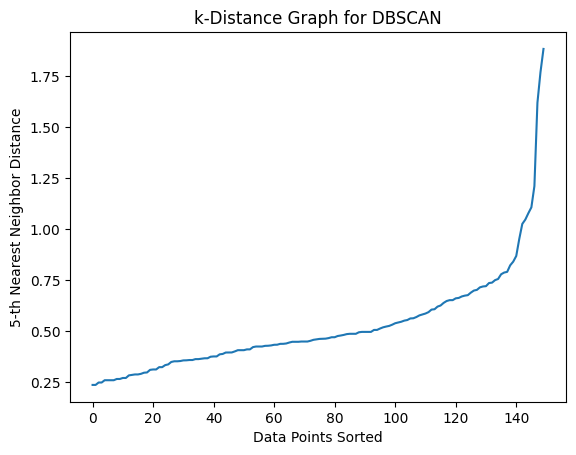

In [3]:
from sklearn.neighbors import NearestNeighbors

# Compute the k-distance for min_samples=5
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# Sort and plot distances
distances = np.sort(distances[:, k-1])  # Get the k-th nearest distances
plt.plot(distances)
plt.xlabel("Data Points Sorted")
plt.ylabel(f"{k}-th Nearest Neighbor Distance")
plt.title("k-Distance Graph for DBSCAN")
plt.show()

```OR```

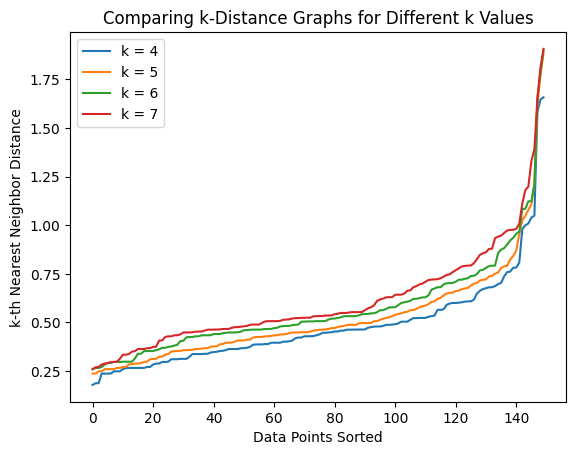

In [14]:
# Try different k values and check the k-distance plot
for k in [4, 5, 6, 7]:
    nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
    distances, _ = nbrs.kneighbors(X_scaled)
    distances = np.sort(distances[:, k-1])

    plt.plot(distances, label=f"k = {k}")

plt.xlabel("Data Points Sorted")
plt.ylabel("k-th Nearest Neighbor Distance")
plt.title("Comparing k-Distance Graphs for Different k Values")
plt.legend()
plt.show()

In [15]:
# Apply DBSCAN with chosen eps and min_samples
dbscan = DBSCAN(eps=1.00, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Add labels to a DataFrame
df = pd.DataFrame(X, columns=iris.feature_names)
df["Cluster"] = labels
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


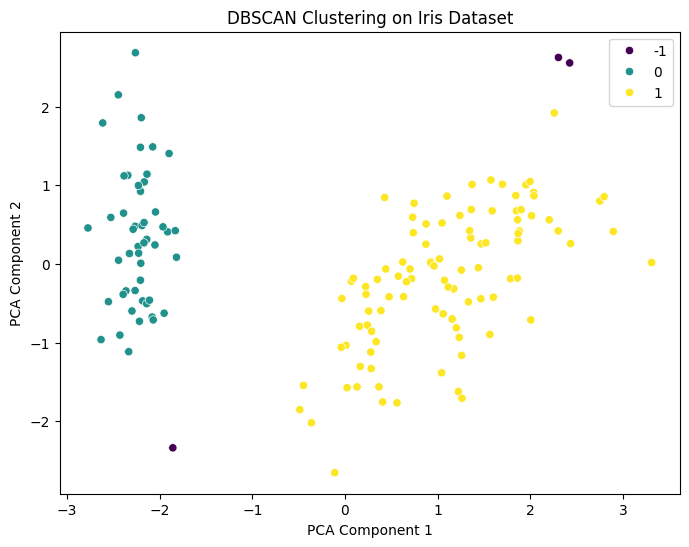

In [16]:
# Reduce dimensions using PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette="viridis", legend="full")
plt.title("DBSCAN Clustering on Iris Dataset")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [17]:
num_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # Ignore noise points (-1)
num_outliers = list(labels).count(-1)

print(f"Number of Clusters: {num_clusters}")
print(f"Number of Outliers: {num_outliers}")

Number of Clusters: 2
Number of Outliers: 3
